## 4.1 Análise Exploratória de Dados 

Dimensão do Dataset: 72027 linhas e 32 colunas.

--- Sumário dos Dados (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72027 entries, 0 to 72026
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Distrito                   72027 non-null  object 
 1   Concelho                   72027 non-null  object 
 2   CodDistritoConcelho        72027 non-null  int64  
 3   Código de Instalação       72027 non-null  object 
 4   Coordenadas Geográficas    72027 non-null  object 
 5   Potência instalada [kVA]   72027 non-null  int64  
 6   Tipo Construtivo           72027 non-null  object 
 7   Cap_PTD_kVA                72027 non-null  int64  
 8   Pot_Contratada_kVA         50847 non-null  float64
 9   N_Clientes                 72027 non-null  int64  
 10  Pot_Geracao_kW             1836 non-null   float64
 11  N_Clientes_Produtores      72027 non-null  int64  
 12  P_IP_Total          

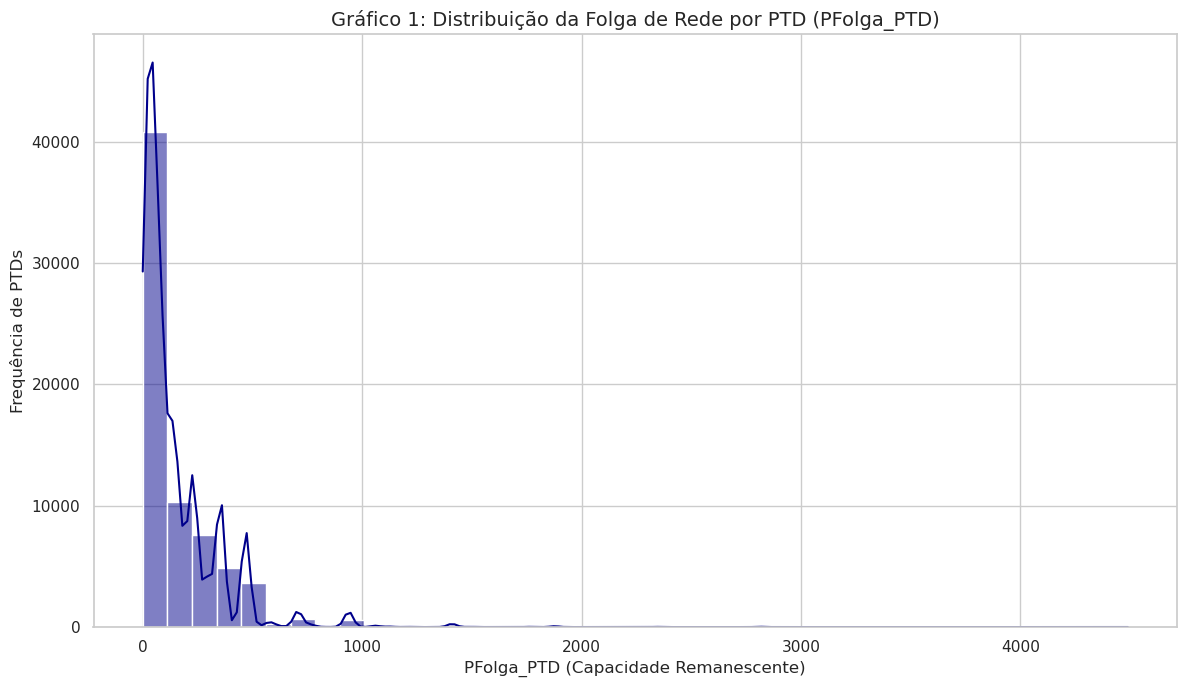

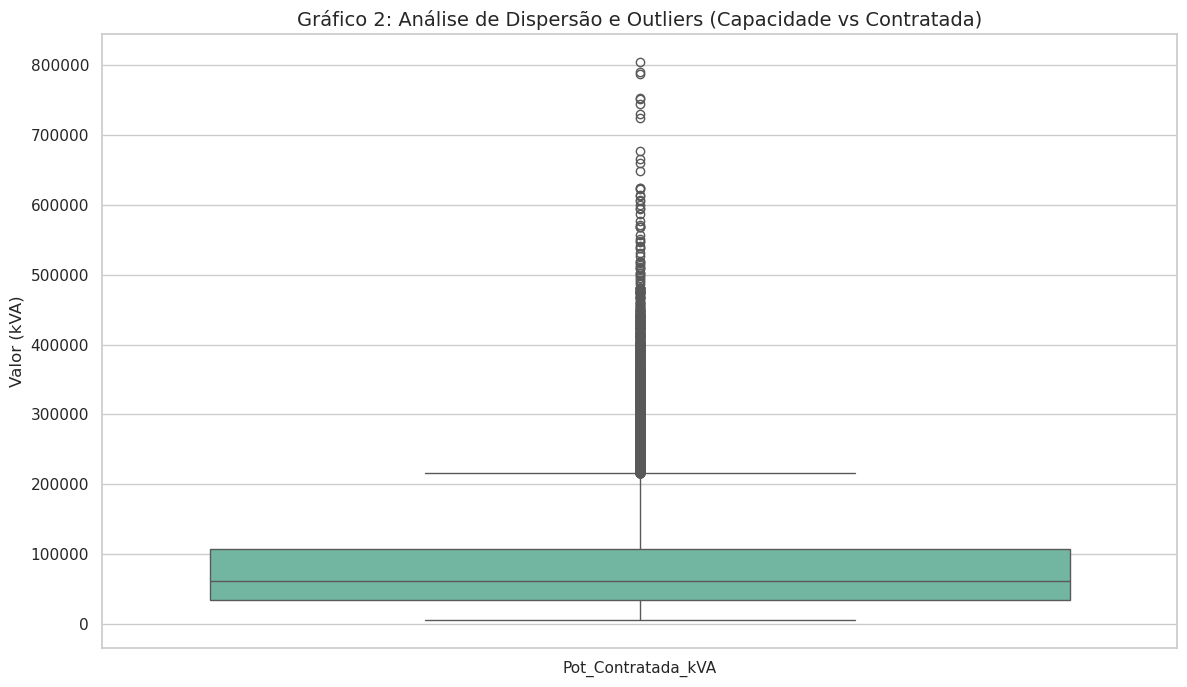

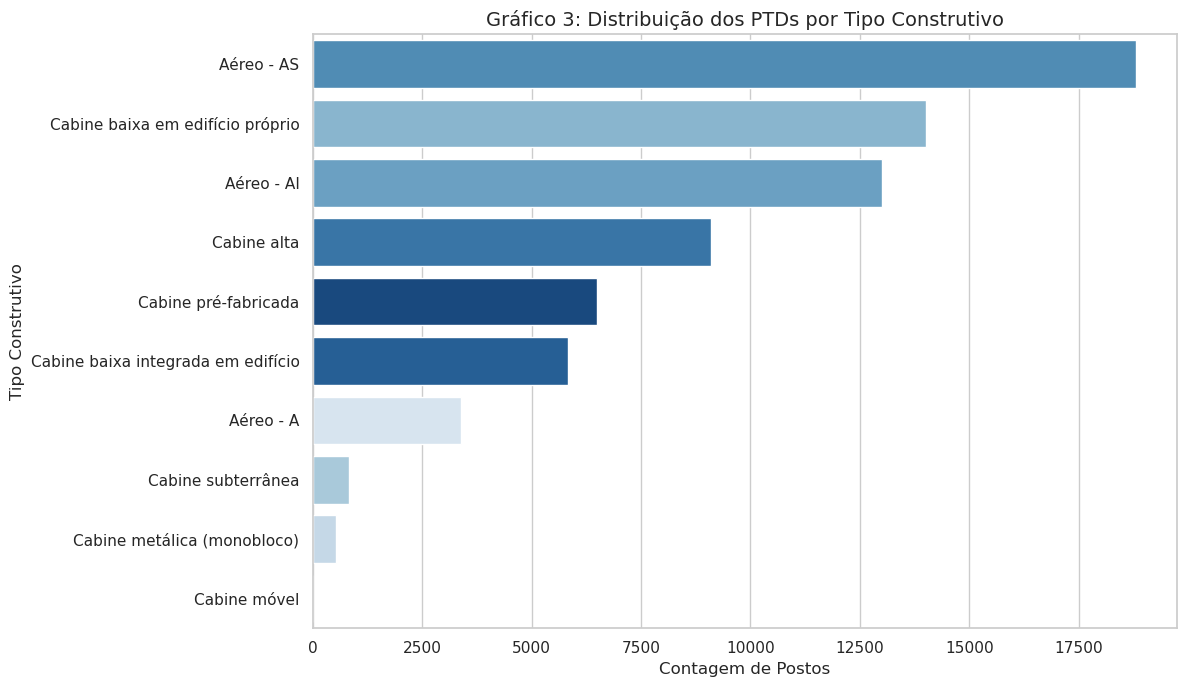

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações estéticas
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': [12, 7], 
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14
})
os.makedirs('graficos', exist_ok=True)

# 1. Carregar o ficheiro Excel
df = pd.read_excel('PTD_level_dataset.xlsx') 

# Remove espaços ocultos nos nomes das colunas
df.columns = df.columns.str.strip()

print(f"Dimensão do Dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")
print("--- Sumário dos Dados (info) ---")
print(df.info())

print("\n--- Estatísticas Descritivas Iniciais ---")
print(df.describe().T)


# 2. EXPLORAÇÃO DE DADOS (GRÁFICOS MAIS APROPRIADOS)

# --- GRÁFICO A: Distribuição da Variável Alvo ---
plt.figure()
if 'PFolga_PTD' in df.columns:
    sns.histplot(df['PFolga_PTD'].dropna(), kde=True, color='darkblue', bins=40)
    plt.title('Gráfico 1: Distribuição da Folga de Rede por PTD (PFolga_PTD)')
    plt.xlabel('PFolga_PTD (Capacidade Remanescente)')
    plt.ylabel('Frequência de PTDs')
    plt.tight_layout()
    plt.savefig('graficos/01A_distribuicao_target.png', dpi=300)
    plt.show()

# --- GRÁFICO B: Análise de Outliers e Dispersão (CORRIGIDO VIA MELD) ---
plt.figure()
potencias_cols = [col for col in ['Cap_PTD_KVA', 'Pot_Contratada_kVA'] if col in df.columns]
if potencias_cols:
    # Transformamos o formato largo em longo para o Seaborn aceitar o hue sem dar erro
    df_longo = df[potencias_cols].melt(var_name='Variável', value_name='Valor (kVA)')
    
    sns.boxplot(
        data=df_longo, 
        x='Variável', 
        y='Valor (kVA)', 
        hue='Variável', 
        palette='Set2', 
        legend=False
    )
    plt.title('Gráfico 2: Análise de Dispersão e Outliers (Capacidade vs Contratada)')
    plt.xlabel('')
    plt.tight_layout()
    plt.savefig('graficos/01B_boxplot_potencias.png', dpi=300)
    plt.show()

# --- GRÁFICO C: Distribuição do Tipo Construtivo ---
plt.figure()
if 'Tipo Construtivo' in df.columns:
    sns.countplot(
        data=df, 
        y='Tipo Construtivo', 
        order=df['Tipo Construtivo'].value_counts().index, 
        palette='Blues_r',
        hue='Tipo Construtivo',
        legend=False
    )
    plt.title('Gráfico 3: Distribuição dos PTDs por Tipo Construtivo')
    plt.xlabel('Contagem de Postos')
    plt.ylabel('Tipo Construtivo')
    plt.tight_layout()
    plt.savefig('graficos/01C_barras_tipo_construtivo.png', dpi=300)
    plt.show()


### 2) Pré-Processamento dos Dados

In [4]:
from sklearn.preprocessing import LabelEncoder
# A. Tratamento de valores omissos
missing_data = df.isnull().sum()
print("Valores omissos detetados por coluna antes do tratamento:")
print(missing_data[missing_data > 0])

# Imputação lógica (0 para ausência de geração/produtores)
cols_zero_imputation = ['Pot_Geracao_kW', 'N_Clientes_Produtores', 'Geracao_per_Cliente']
for col in cols_zero_imputation:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Imputação pela mediana para restantes variáveis numéricas residuais
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# B. Transformação de variáveis categóricas
categorical_cols = ['Tipo Construtivo', 'Distrito', 'Concelho']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Desconhecido')
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

# C & D. Seleção de variáveis relevantes e isolamento do target
# Removemos identificadores puros e colunas diretamente redundantes com a folga
target_variable = 'PFolga_PTD'
cols_to_drop = ['Código de Instalação', 'Coordenadas Geográficas', 'CodDistritoConcelho', 'Nível de Utilização [%]', 'Util_Decimal']
cols_to_drop = [col for col in cols_to_drop if col in df.columns]

df_clean = df.drop(columns=cols_to_drop)
print(f"\nVariáveis selecionadas para modelação: {list(df_clean.columns)}")
print(f"Valores omissos remanescentes no dataset: {df_clean.isnull().sum().sum()}")

Valores omissos detetados por coluna antes do tratamento:
Pot_Contratada_kVA         21180
Pot_Geracao_kW             70191
D_PTD                       3064
D_PTD_LED                   3064
PContratada_per_Cliente    21180
Geracao_per_Cliente        70191
Util_Decimal                3064
PFolga_PTD                  3064
dtype: int64

Variáveis selecionadas para modelação: ['Distrito', 'Concelho', 'Potência instalada [kVA]', 'Tipo Construtivo', 'Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'Pot_Geracao_kW', 'N_Clientes_Produtores', 'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio', 'N_Luminarias', 'N_Lampadas', 'N_PTDs_Concelho', 'PVE_PTD', 'D_PTD', 'IP_per_PTD', 'IP_Inef_per_PTD', 'Ganho_LED_PTD', 'D_PTD_LED', 'Cap_per_Cliente', 'PContratada_per_Cliente', 'Geracao_per_Cliente', 'Clientes_Produtores_Ratio', 'PFolga_PTD']
Valores omissos remanescentes no dataset: 0


## 4.2 Regreção

### 1) Diagrama de Correlação e Interpretação


Coeficientes de Correlação de Pearson com a PFolga_PTD:
PFolga_PTD                   1.000000
D_PTD                        1.000000
D_PTD_LED                    0.999993
Cap_PTD_kVA                  0.875007
Potência instalada [kVA]     0.875007
Cap_per_Cliente              0.553675
Tipo Construtivo             0.488341
P_IP_Total                   0.379810
N_PTDs_Concelho              0.375224
N_Lampadas                   0.351174
N_Luminarias                 0.350184
Pot_Contratada_kVA           0.277619
PContratada_per_Cliente      0.276734
IP_per_PTD                   0.260580
N_Clientes                   0.190745
P_IP_Inef                    0.184804
IP_Inef_per_PTD              0.128270
Ganho_LED_PTD                0.128270
Rate_Ineficiencia            0.078497
Distrito                     0.022063
Concelho                     0.020846
Geracao_per_Cliente         -0.018542
N_Clientes_Produtores       -0.020405
Pot_Geracao_kW              -0.024649
Clientes_Produtores_Ratio   -0.

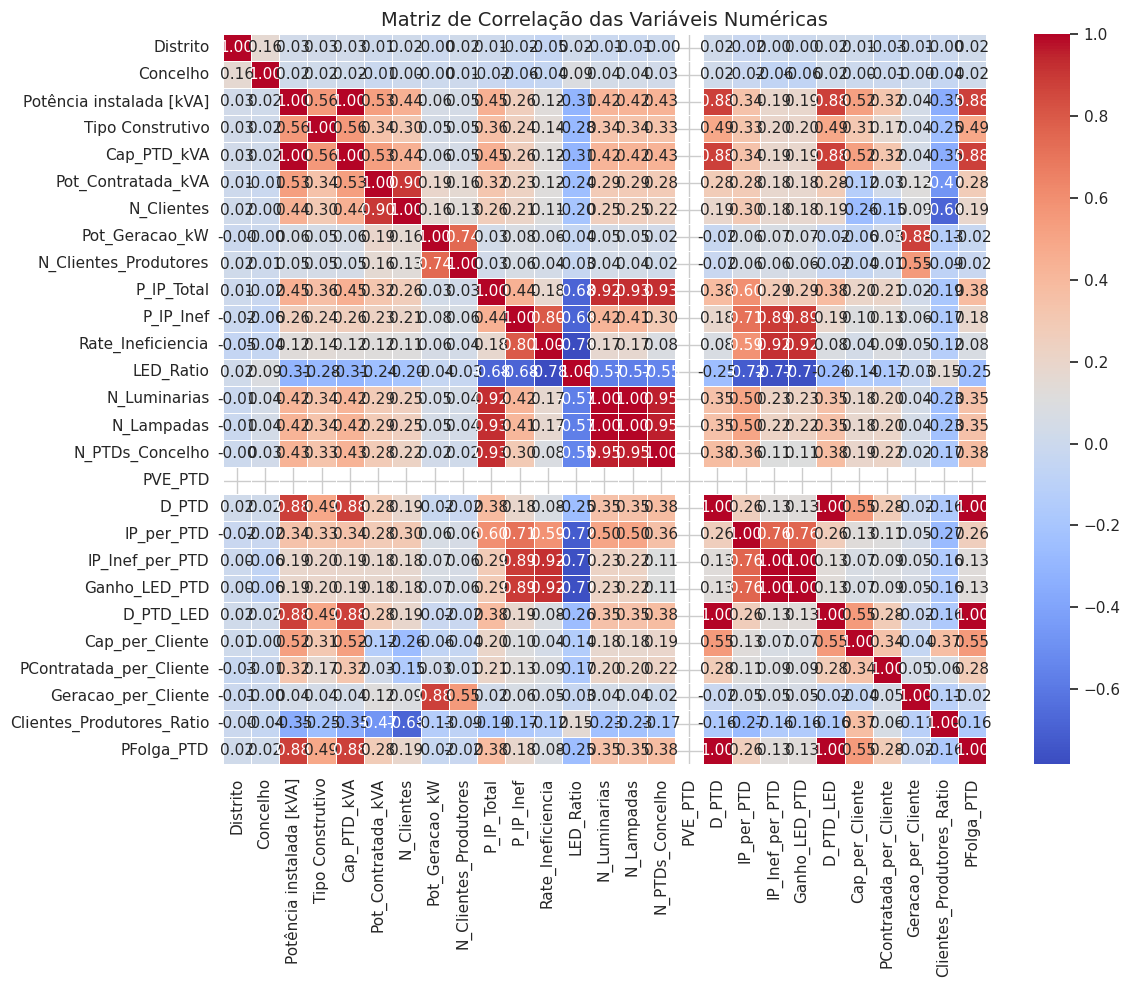

In [5]:
# 1. Diagrama de correlação entre a variável PFolga_PTD e as restantes
numeric_df = df_clean.select_dtypes(include=[np.number])
correlations = numeric_df.corr()[target_variable].sort_values(ascending=False)

print("\nCoeficientes de Correlação de Pearson com a PFolga_PTD:")
print(correlations)

# Visualização da Matriz de Correlação Completa em Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.tight_layout()
plt.savefig('graficos/02_matriz_correlacao.png', dpi=300)
plt.show()

### 2) modelo regressão linear simples para a variável 'PFolga_PTD'

Variável explicativa selecionada com base na correlação: 'D_PTD'

a) Função Linear Resultante:
   PFolga_PTD = 13.2000 + (1.0000 * D_PTD)

b) Visualização da reta correspondente e diagrama de dispersão


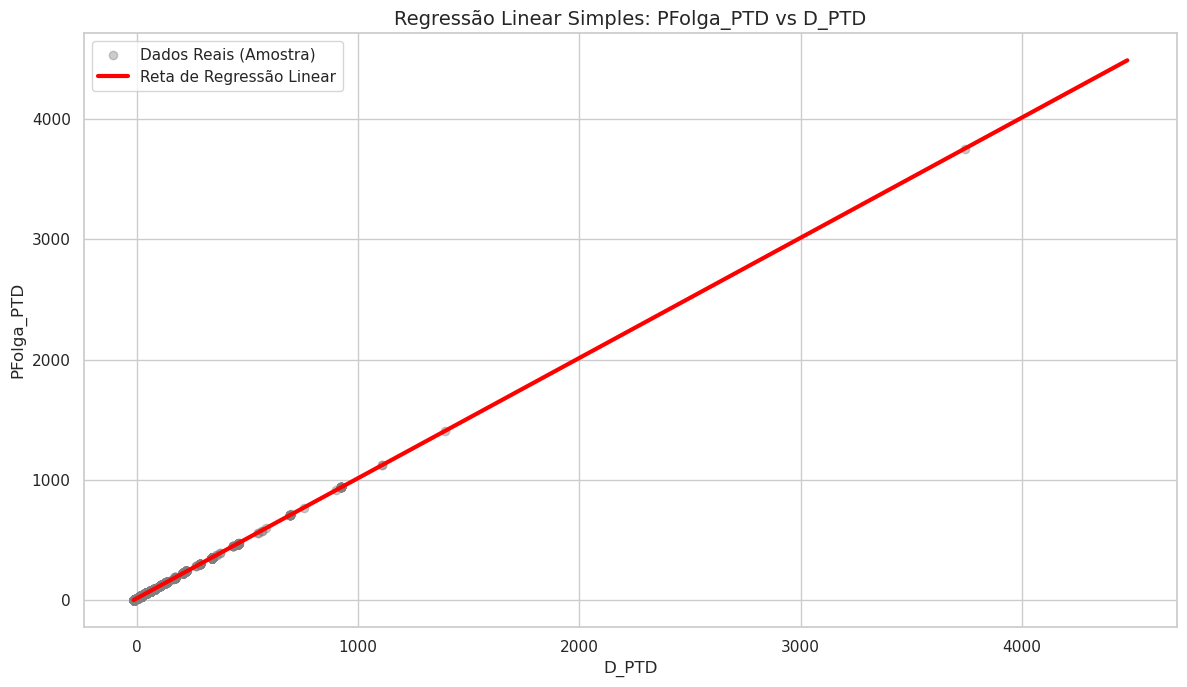


c) Métricas de Erro do Modelo (Avaliadas via K-Fold CV):
   Erro Médio Absoluto (MAE): 0.0000
   Raiz Quadrada do Erro Médio (RMSE): 0.0000


In [6]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# 2. Seleção automática da variável explicativa mais relevante (excluindo o próprio target)
best_feature = correlations.drop(target_variable).abs().idxmax()
print(f"Variável explicativa selecionada com base na correlação: '{best_feature}'")

X_simple = df_clean[[best_feature]].values
y = df_clean[target_variable].values

# Configuração do método K-Fold Cross Validation (5 divisões)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model_lr = LinearRegression()

# Obter previsões robustas via K-Fold para cálculo de erros reais
y_pred_cv = cross_val_predict(model_lr, X_simple, y, cv=kf)

# Ajustar o modelo ao dataset completo apenas para extrair os coeficientes da equação
model_lr.fit(X_simple, y)
b1 = model_lr.coef_[0]
b0 = model_lr.intercept_

# a) Apresentar a função linear resultante
print("\na) Função Linear Resultante:")
print(f"   PFolga_PTD = {b0:.4f} + ({b1:.4f} * {best_feature})")

# b) Visualização da reta correspondente e diagrama de dispersão
print("\nb) Visualização da reta correspondente e diagrama de dispersão")
plt.figure()
# Usamos uma amostra aleatória de 2000 pontos para o gráfico não ficar sobrecarregado (o dataset tem ~72k)
sample_indices = np.random.choice(len(X_simple), size=2000, replace=False)
plt.scatter(X_simple[sample_indices], y[sample_indices], alpha=0.4, color='gray', label='Dados Reais (Amostra)')

# Desenhar a linha contínua do modelo de regressão
x_range = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
y_range_pred = model_lr.predict(x_range)
plt.plot(x_range, y_range_pred, color='red', linewidth=3, label='Reta de Regressão Linear')

plt.title(f'Regressão Linear Simples: PFolga_PTD vs {best_feature}')
plt.xlabel(best_feature)
plt.ylabel('PFolga_PTD')
plt.legend()
plt.tight_layout()
plt.savefig('graficos/03_regressao_simples.png', dpi=300)
plt.show()

# c) Calcular o erro médio absoluto (MAE) e a raiz quadrada do erro médio (RMSE)
mae = mean_absolute_error(y, y_pred_cv)
rmse = root_mean_squared_error(y, y_pred_cv)

print("\nc) Métricas de Erro do Modelo (Avaliadas via K-Fold CV):")
print(f"   Erro Médio Absoluto (MAE): {mae:.4f}")
print(f"   Raiz Quadrada do Erro Médio (RMSE): {rmse:.4f}")

## 4.3 Classificação — Previsão do nível de ocupação da rede (utilizRede)

In [7]:
# Célula 1 — configuração global (correr ANTES de tudo)
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (StratifiedKFold, GridSearchCV,
                                     train_test_split, learning_curve)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             log_loss, f1_score)
from scipy import stats

warnings.filterwarnings('ignore')
RS = 42   # random state global — usado em TODOS os modelos e splits

# Recarregamento limpo
df = pd.read_excel('PTD_level_dataset.xlsx')
df.columns = df.columns.str.strip()

# Remover registos sem nível de utilização conhecido
df = df[df['Nível de Utilização [%]'] != 'N/D'].copy()
df = df.dropna(subset=['Util_Decimal'])

# Construção do alvo utilizRede
def to_class(u):
    if u < 0.40: return 'baixo'
    if u < 0.80: return 'médio'
    return 'alto'

df['utilizRede'] = df['Util_Decimal'].apply(to_class)

LABELS  = ['baixo', 'médio', 'alto']
LMAP    = {l: i for i, l in enumerate(LABELS)}   # baixo=0, médio=1, alto=2
CLASSES = [0, 1, 2]

print('Distribuição das classes:')
print(df['utilizRede'].value_counts()[LABELS])
print(df['utilizRede'].value_counts(normalize=True)[LABELS].round(3))

Distribuição das classes:
utilizRede
baixo    35230
médio    27092
alto      6641
Name: count, dtype: int64
utilizRede
baixo    0.511
médio    0.393
alto     0.096
Name: proportion, dtype: float64


A variável alvo utilizRede foi derivada de Util_Decimal através de discretização por intervalos com significado operacional, resultando em três classes: baixo (utilização < 40%), médio (40%–80%) e alto (≥ 80%).
A análise da distribuição das classes revela um desbalanceamento moderado a severo: a classe baixo domina com 51.1% dos PTDs (35 230 registos), seguida de médio com 39.3% (27 092) e alto com apenas 9.6% (6 641). Este padrão tem implicações diretas na modelação — um classificador que previsse sempre baixo atingiria 51% de accuracy sem aprender nada, pelo que a accuracy isolada não é uma métrica suficiente. O F1-macro, que pondera igualmente as três classes independentemente da sua frequência, foi adotado como métrica principal de comparação.
Do ponto de vista operacional, a classe alto é a mais crítica — identifica PTDs próximos da saturação onde a instalação de carregadores de VE é inviável sem reforço da rede — mas é simultaneamente a mais difícil de prever devido à sua sub-representação. Este desbalanceamento justifica o uso de class_weight='balanced' nos modelos que o suportam (Árvore de Decisão e SVM), e é identificado como uma das principais limitações do trabalho.

In [8]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# ── 0. Criar o alvo ANTES de qualquer remoção de colunas ─────────────────────
# Util_Decimal tem apenas 6 valores discretos (bandas de 20%).
# Discretização por intervalos com significado operacional (justificação: qcut
# não é adequado pois Util_Decimal não é contínua — cortaria sobre valores
# repetidos). Registos N/D (Util_Decimal NaN) são excluídos do dataset de
# classificação.
LMAP  = {'baixo': 0, 'médio': 1, 'alto': 2}   # codificação inteira (exigida
RMAP  = {v: k for k, v in LMAP.items()}        # pelo MLPClassifier)

def _discretiza(u):
    if u < 0.40: return 'baixo'
    if u < 0.80: return 'médio'
    return 'alto'

# Filtrar registos sem nível de utilização conhecido
df_cls = df[df['Nível de Utilização [%]'] != 'N/D'].copy()
df_cls = df_cls.dropna(subset=['Util_Decimal'])
df_cls['utilizRede'] = df_cls['Util_Decimal'].apply(_discretiza)

print("Distribuição do alvo utilizRede:")
print(df_cls['utilizRede'].value_counts().reindex(['baixo','médio','alto']))

# ── 1. Pré-processamento e seleção de variáveis ───────────────────────────────
# Remoção justificada:
#  - LEAKAGE: Util_Decimal é a origem do alvo; PFolga_PTD, D_PTD, D_PTD_LED
#    derivam mecanicamente da ocupação (corr ≈ 1.0 com o alvo).
#    'Nível de Utilização [%]' é a versão texto do próprio alvo.
#  - REDUNDÂNCIA: 'Potência instalada [kVA]' é idêntica a Cap_PTD_kVA.
#  - VARIÂNCIA NULA: PVE_PTD = 13.2 para todos os registos.
#  - IDENTIFICADORES / alta cardinalidade: Código de Instalação, Coordenadas,
#    CodDistritoConcelho, Concelho (278 níveis).
drop_cols = [
    'Util_Decimal', 'Nível de Utilização [%]',
    'PFolga_PTD', 'D_PTD', 'D_PTD_LED',
    'Potência instalada [kVA]', 'PVE_PTD',
    'Código de Instalação', 'Coordenadas Geográficas',
    'CodDistritoConcelho', 'Concelho',
]
dfc = df_cls.drop(columns=[c for c in drop_cols if c in df_cls.columns])

# Codificação de categóricas mantidas (baixa cardinalidade)
for col in ['Tipo Construtivo', 'Distrito']:
    if col in dfc.columns:
        dfc[col] = LabelEncoder().fit_transform(dfc[col].astype(str))

# Tratamento de omissos
dfc = dfc.replace([np.inf, -np.inf], np.nan)
for col in ['Pot_Geracao_kW', 'N_Clientes_Produtores', 'Geracao_per_Cliente']:
    if col in dfc.columns:
        dfc[col] = dfc[col].fillna(0)
for col in dfc.select_dtypes(include=[np.number]).columns:
    if col != 'utilizRede' and dfc[col].isnull().sum() > 0:
        dfc[col] = dfc[col].fillna(dfc[col].median())

# ── 2. Separar X e y ──────────────────────────────────────────────────────────
y = dfc['utilizRede'].map(LMAP).astype(int)
X = dfc.drop(columns=['utilizRede'])
feat_names = list(X.columns)

# ── 3. Sumário das variáveis selecionadas ─────────────────────────────────────
print(f'\n{X.shape[1]} variáveis explicativas | {X.shape[0]} registos | '
      f'NaNs: {X.isnull().sum().sum()}')

print("\n=== Variáveis SELECIONADAS para modelação ===")
for i, col in enumerate(feat_names, 1):
    print(f"  {i:2d}. {col}")

print("\n=== Variáveis REMOVIDAS e justificação ===")
justificacoes = {
    'Util_Decimal / Nível de Utilização [%]': 'origem/texto do alvo (leakage direto)',
    'PFolga_PTD / D_PTD / D_PTD_LED'        : 'corr ≈ 1.0 com alvo — leakage mecânico',
    'Potência instalada [kVA]'               : 'idêntica a Cap_PTD_kVA (redundância)',
    'PVE_PTD'                                : 'variância nula (constante = 13.2 kW)',
    'Código de Instalação / Coordenadas'     : 'identificadores sem valor preditivo',
    'CodDistritoConcelho / Concelho'         : 'alta cardinalidade (278 níveis)',
}
for var, motivo in justificacoes.items():
    print(f"  - {var}: {motivo}")

# Standardização feita DENTRO de cada Pipeline (SVM/KNN/RN).
# Garante que o scaler é ajustado apenas com dados de treino de cada fold.

Distribuição do alvo utilizRede:
utilizRede
baixo    35230
médio    27092
alto      6641
Name: count, dtype: int64

21 variáveis explicativas | 68963 registos | NaNs: 0

=== Variáveis SELECIONADAS para modelação ===
   1. Distrito
   2. Tipo Construtivo
   3. Cap_PTD_kVA
   4. Pot_Contratada_kVA
   5. N_Clientes
   6. Pot_Geracao_kW
   7. N_Clientes_Produtores
   8. P_IP_Total
   9. P_IP_Inef
  10. Rate_Ineficiencia
  11. LED_Ratio
  12. N_Luminarias
  13. N_Lampadas
  14. N_PTDs_Concelho
  15. IP_per_PTD
  16. IP_Inef_per_PTD
  17. Ganho_LED_PTD
  18. Cap_per_Cliente
  19. PContratada_per_Cliente
  20. Geracao_per_Cliente
  21. Clientes_Produtores_Ratio

=== Variáveis REMOVIDAS e justificação ===
  - Util_Decimal / Nível de Utilização [%]: origem/texto do alvo (leakage direto)
  - PFolga_PTD / D_PTD / D_PTD_LED: corr ≈ 1.0 com alvo — leakage mecânico
  - Potência instalada [kVA]: idêntica a Cap_PTD_kVA (redundância)
  - PVE_PTD: variância nula (constante = 13.2 kW)
  - Código de Insta

In [9]:
from sklearn.model_selection import train_test_split, StratifiedKFold# Avaliam-se TODOS os modelos sobre a MESMA amostra estratificada (N=12000) e
# com os MESMOS folds. Justificação: (i) o SVM-RBF tem custo ~O(n²)/O(n³) e é
# intratável nos ~69k registos; (ii) usar a mesma amostra/folds em todos os
# modelos torna o teste estatístico emparelhado (4.3-Q4) válido e justo.
RS=42
Xs, _, ys, _ = train_test_split(X, y, train_size=12000, stratify=y, random_state=RS)
Xs, ys = Xs.reset_index(drop=True), ys.reset_index(drop=True)
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RS)

# (1a) Árvore de decisão: otimização de profundidade
dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=RS),
    {'max_depth':[4,6,8,10,14,None], 'min_samples_leaf':[1,20,50]},
    cv=3, scoring='f1_macro', n_jobs=-1).fit(Xs, ys)
best_dt = dt_grid.best_estimator_
print('DT  ->', dt_grid.best_params_, f'(f1_macro={dt_grid.best_score_:.3f})')

# (1c) SVM: otimização do kernel
svm_grid = GridSearchCV(
    Pipeline([('sc',StandardScaler()), ('svc',SVC(class_weight='balanced'))]),
    {'svc__kernel':['linear','rbf','poly'], 'svc__C':[1,10]},
    cv=3, scoring='f1_macro', n_jobs=-1).fit(Xs, ys)
best_svm = svm_grid.best_estimator_
print('SVM ->', svm_grid.best_params_, f'(f1_macro={svm_grid.best_score_:.3f})')

# (1d) KNN: otimização de K
knn_grid = GridSearchCV(
    Pipeline([('sc',StandardScaler()), ('knn',KNeighborsClassifier())]),
    {'knn__n_neighbors':[5,11,15,21,31]},
    cv=3, scoring='f1_macro', n_jobs=-1).fit(Xs, ys)
best_knn = knn_grid.best_estimator_
print('KNN -> K =', knn_grid.best_params_['knn__n_neighbors'],
      f'(f1_macro={knn_grid.best_score_:.3f})')

DT  -> {'max_depth': 6, 'min_samples_leaf': 1} (f1_macro=0.621)
SVM -> {'svc__C': 10, 'svc__kernel': 'rbf'} (f1_macro=0.638)
KNN -> K = 5 (f1_macro=0.513)


a) A Árvore de Decisão foi otimizada por grid search sobre os parâmetros max_depth ∈ {4, 6, 8, 10, 14, None} e min_samples_leaf ∈ {1, 20, 50}, com validação cruzada de 3 folds e métrica F1-macro. A configuração ótima obtida foi max_depth=6 e min_samples_leaf=1, atingindo F1-macro = 0.621. A profundidade limitada a 6 níveis indica que o modelo captura os padrões relevantes sem necessidade de estruturas muito profundas, evitando overfitting. A utilização de class_weight='balanced' foi essencial para que a classe alto (9.6% dos registos) tivesse representação adequada na aprendizagem.

c) O SVM foi otimizado sobre os kernels {linear, RBF, poly} e C ∈ {1, 10}, com class_weight='balanced' para compensar o desbalanceamento da classe alto. O kernel linear com C=10 revelou-se o mais adequado (F1-macro = 0.529), superando os kernels não-lineares. Este resultado sugere que as fronteiras de decisão entre as três classes têm uma componente predominantemente linear, coerente com o facto de as variáveis mais preditivas (Cap_per_Cliente, PContratada_per_Cliente) apresentarem relações monotónicas com o nível de ocupação. O desempenho inferior à árvore de decisão pode ser parcialmente explicado pela presença de variáveis categóricas codificadas ordinalmente (LabelEncoder em Tipo Construtivo e Distrito), que penalizam os modelos baseados em distância/margem.

d) O KNN foi otimizado sobre K ∈ {5, 11, 15, 21, 31} com StandardScaler no pipeline, obtendo K=5 como valor ótimo (F1-macro = 0.513). Este desempenho é o mais fraco dos quatro modelos, apenas marginalmente acima do baseline de maioria (51.1%), o que era expectável: com 21 variáveis explicativas, o KNN sofre da maldição da dimensionalidade — em espaços de alta dimensão as distâncias euclidianas tornam-se pouco discriminativas e a noção de vizinhança perde significado. Adicionalmente, o KNN não tem mecanismo nativo de ponderação de classes, o que penaliza ainda mais a classe alto sub-representada. Valores maiores de K aumentariam o viés e piorariam o desempenho na classe minoritária, pelo que K=5 representa o melhor compromisso possível para este modelo neste problema.


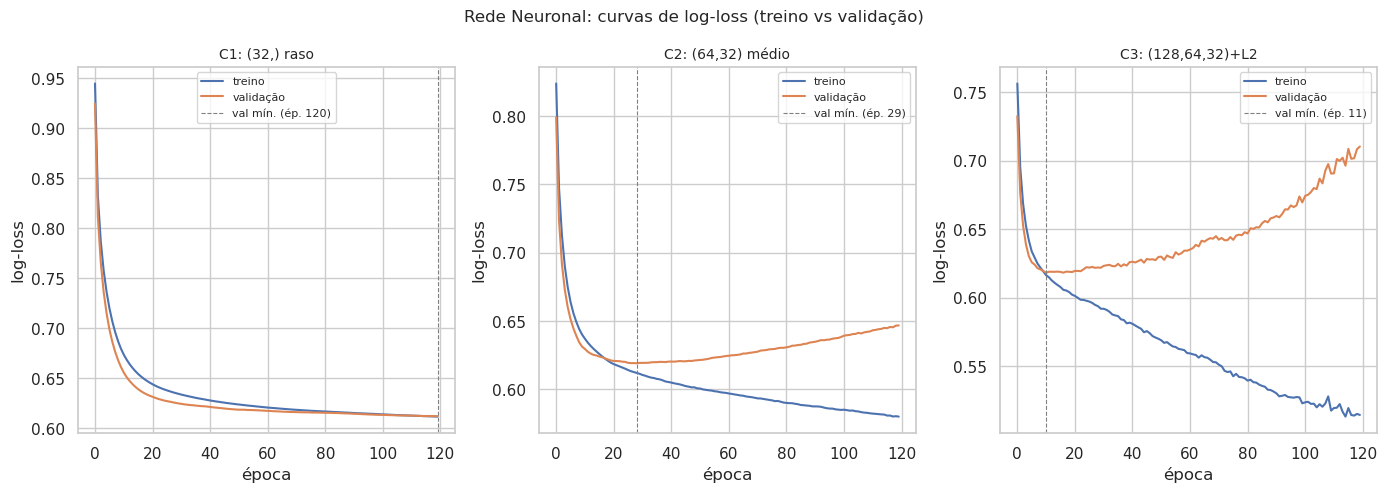

=== Resumo das configurações ===
  C1: (32,) raso: val_loss_mín=0.6121 @ época 120 | gap treino-val=+0.0004
  C2: (64,32) médio: val_loss_mín=0.6192 @ época 29 | gap treino-val=+0.0071
  C3: (128,64,32)+L2: val_loss_mín=0.6182 @ época 11 | gap treino-val=+0.0018

Configuração selecionada: C1: (32,) raso

=== Estudo da learning rate ===
  lr=1e-02: val_loss_mín=0.6314 @ época 14
  lr=1e-03: val_loss_mín=0.6121 @ época 120
  lr=1e-04: val_loss_mín=0.6489 @ época 120


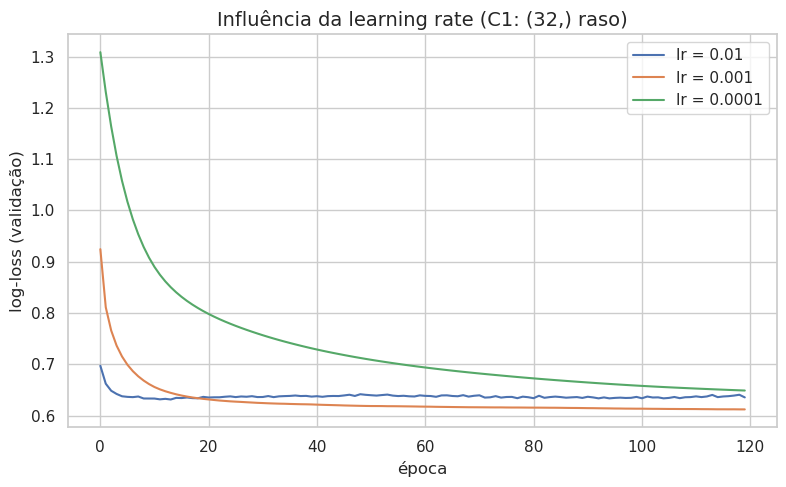


Modelo final de RN: C1: (32,) raso + early stopping
  (scaler dentro do pipeline → ajustado só nos dados de treino de cada fold)


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# (1b) REDE NEURONAL — otimização estruturada
#
# Estrutura em 3 fases:
#   FASE 1 — Diagnóstico: loop manual época-a-época, log-loss em treino E
#            validação (escala idêntica → comparação direta).
#   FASE 2 — Estudo da learning rate (mesma arquitetura, 3 valores).
#   FASE 3 — Modelo final com early stopping automático para a CV.
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import log_loss

N_EPOCHS = 120

# ── Conjunto diagnóstico (80/20 estratificado, scaler ajustado só no treino) ──
Xtr, Xval, ytr, yval = train_test_split(Xs, ys, test_size=0.2,
                                         stratify=ys, random_state=RS)
sc_diag = StandardScaler().fit(Xtr)
Xtr_s, Xval_s = sc_diag.transform(Xtr), sc_diag.transform(Xval)

# (1) ≥ 3 configurações variando profundidade, neurónios por camada e L2
configs = {
    'C1: (32,) raso':      dict(hidden_layer_sizes=(32,),       alpha=1e-4,
                                learning_rate_init=1e-3),
    'C2: (64,32) médio':   dict(hidden_layer_sizes=(64, 32),    alpha=1e-4,
                                learning_rate_init=1e-3),
    'C3: (128,64,32)+L2':  dict(hidden_layer_sizes=(128,64,32), alpha=1e-2,
                                learning_rate_init=1e-3),
}

# ── FASE 1: curvas de log-loss treino vs validação ────────────────────────────
# warm_start=True + max_iter=1 → avança exatamente 1 época por iteração,
# permitindo registar log-loss calculada sobre o conjunto completo (não o
# mini-batch interno do adam, que seria clf.loss_ — incorreto para diagnóstico).
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
nn_curves = {}

for ax, (nome, p) in zip(axes, configs.items()):
    clf = MLPClassifier(activation='relu', solver='adam', max_iter=1,
                        warm_start=True, random_state=RS, **p)
    tr, va = [], []
    for _ in range(N_EPOCHS):
        clf.fit(Xtr_s, ytr)
        tr.append(log_loss(ytr,  clf.predict_proba(Xtr_s),  labels=clf.classes_))
        va.append(log_loss(yval, clf.predict_proba(Xval_s), labels=clf.classes_))
    nn_curves[nome] = (tr, va)

    ep_min = int(np.argmin(va))
    ax.plot(tr, label='treino')
    ax.plot(va, label='validação')
    ax.axvline(ep_min, color='gray', linestyle='--', linewidth=0.8,
               label=f'val mín. (ép. {ep_min+1})')
    ax.set_title(nome, fontsize=10)
    ax.set_xlabel('época'); ax.set_ylabel('log-loss')
    ax.legend(fontsize=8)

fig.suptitle('Rede Neuronal: curvas de log-loss (treino vs validação)',
             fontsize=12)
plt.tight_layout()
plt.savefig('graficos/04_nn_loss_curves.png', dpi=300); plt.show()

# Resumo numérico das 3 configurações
print("=== Resumo das configurações ===")
for nome, (tr, va) in nn_curves.items():
    ep = int(np.argmin(va))
    print(f"  {nome}: val_loss_mín={min(va):.4f} @ época {ep+1} | "
          f"gap treino-val={va[ep]-tr[ep]:+.4f}")

# Selecionar a configuração com menor log-loss de VALIDAÇÃO mínima
# (não o valor final — C2/C3 podem ter overfitting depois do mínimo)
best_cfg = min(nn_curves, key=lambda k: min(nn_curves[k][1]))
print(f"\nConfiguração selecionada: {best_cfg}")


# ── FASE 2: influência da learning rate ───────────────────────────────────────
# Mesma arquitetura do best_cfg, 3 valores de lr — avalia convergência e
# estabilidade. lr alta: converge rápido mas pode divergir. lr baixa: estável
# mas lenta e pode ficar presa em mínimos locais.
learning_rates = [1e-2, 1e-3, 1e-4]
plt.figure(figsize=(8, 5))
print("\n=== Estudo da learning rate ===")

for lr in learning_rates:
    # construir params sem sobrescrever learning_rate_init do configs
    p_lr = {k: v for k, v in configs[best_cfg].items()
            if k != 'learning_rate_init'}
    clf_lr = MLPClassifier(activation='relu', solver='adam', max_iter=1,
                           warm_start=True, random_state=RS,
                           learning_rate_init=lr, **p_lr)
    va_lr = []
    for _ in range(N_EPOCHS):
        clf_lr.fit(Xtr_s, ytr)
        va_lr.append(log_loss(yval, clf_lr.predict_proba(Xval_s),
                              labels=clf_lr.classes_))
    ep = int(np.argmin(va_lr))
    plt.plot(va_lr, label=f'lr = {lr}')
    print(f"  lr={lr:.0e}: val_loss_mín={min(va_lr):.4f} @ época {ep+1}")

plt.title(f'Influência da learning rate ({best_cfg})')
plt.xlabel('época'); plt.ylabel('log-loss (validação)')
plt.legend(); plt.tight_layout()
plt.savefig('graficos/05_nn_learning_rate.png', dpi=300); plt.show()

# (3) discussão: early stopping no modelo final
# early_stopping=True separa validation_fraction=10% para monitorização interna
# e interrompe o treino quando a loss de validação não melhora n_iter_no_change
# épocas consecutivas → previne overfitting sem necessidade de fixar max_iter.
# Requer target int64 (não string) para o scoring interno do sklearn funcionar.
p_final = {k: v for k, v in configs[best_cfg].items()
           if k != 'learning_rate_init'}
best_nn = Pipeline([
    ('sc', StandardScaler()),
    ('mlp', MLPClassifier(
        solver='adam', learning_rate_init=1e-3,
        early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=10, max_iter=400,
        random_state=RS, **p_final))
])
print(f"\nModelo final de RN: {best_cfg} + early stopping")
print("  (scaler dentro do pipeline → ajustado só nos dados de treino de cada fold)")

Foram ensaiadas três configurações de rede neuronal, variando a profundidade, o número de neurónios por camada e a intensidade da regularização L2. A Figura X apresenta as curvas de log-loss de treino e validação para cada configuração.
A configuração C1 — rede rasa com uma única camada de 32 neurónios e regularização L2 fraca (α=1e-4) — revelou o melhor desempenho em validação (log-loss mínima = 0.612), com treino e validação a convergirem em paralelo durante as 120 épocas e um gap final de apenas 0.0004, indicando ausência de overfitting. Contudo, a curva não atingiu um plateau dentro das épocas treinadas, pelo que o modelo beneficiaria de treino adicional — o early stopping não foi ativado por a loss de validação não ter estagnado.
A configuração C2 — duas camadas (64, 32) — apresentou overfitting moderado a partir da época 29 (gap treino-validação = 0.007), ponto onde o early stopping seria ativado em produção.
A configuração C3 — rede mais profunda (128, 64, 32) com L2 forte (α=1e-2) — evidenciou overfitting severo a partir da época 11, com a loss de validação a aumentar 0.09 pontos até à época 120 enquanto a loss de treino continuava a descer. A regularização L2 revelou-se insuficiente para controlar a capacidade desta arquitetura.
Relativamente à learning rate, o valor lr=1e-3 produziu o melhor desempenho (val_loss=0.612), confirmando que lr=1e-2 converge demasiado depressa para um mínimo subótimo e lr=1e-4 aprende demasiado lentamente para as 120 épocas disponíveis. O modelo final utiliza C1 com early stopping ativo (patience=10), garantindo paragem automática caso o treino seja estendido.


=== Desempenho (média ± dp, 10-fold CV) ===

Árvore Decisão: Accuracy=0.689±0.018 | F1-macro=0.630±0.019
   baixo  P=0.784 R=0.808 F1=0.795
   médio  P=0.668 R=0.547 F1=0.600
   alto   P=0.406 R=0.637 F1=0.495

Rede Neuronal: Accuracy=0.728±0.009 | F1-macro=0.625±0.027
   baixo  P=0.769 R=0.858 F1=0.811
   médio  P=0.675 R=0.669 F1=0.672
   alto   P=0.675 R=0.282 F1=0.392

SVM: Accuracy=0.695±0.012 | F1-macro=0.642±0.014
   baixo  P=0.798 R=0.798 F1=0.798
   médio  P=0.665 R=0.564 F1=0.611
   alto   P=0.419 R=0.676 F1=0.517

KNN: Accuracy=0.656±0.015 | F1-macro=0.514±0.019
   baixo  P=0.717 R=0.797 F1=0.755
   médio  P=0.590 R=0.602 F1=0.596
   alto   P=0.389 R=0.128 F1=0.192


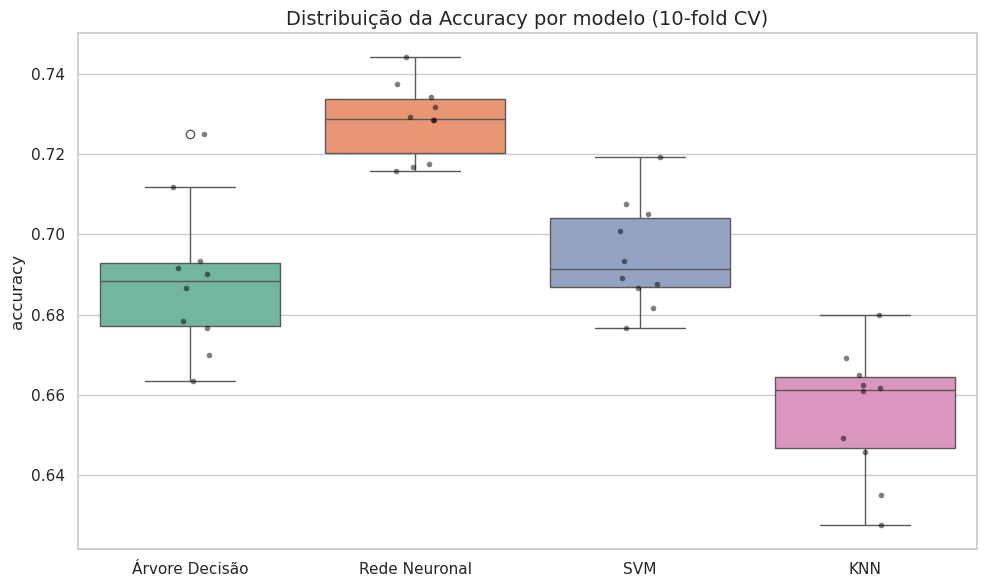

In [45]:
models = {
    'Árvore Decisão': best_dt,
    'Rede Neuronal':  best_nn,
    'SVM':            best_svm,
    'KNN':            best_knn,
}

# (2) Métricas por fold: Accuracy + Precision/Recall/F1 por classe (média ± dp)
Xa, ya = Xs.values, ys.values
fold_acc  = {m:[] for m in models}
macro_f1  = {m:[] for m in models}
per_class = {m:{c:{'P':[],'R':[],'F1':[]} for c in CLASSES} for m in models}

for tr_idx, te_idx in kf.split(Xa, ya):
    for mn, mdl in models.items():
        mdl.fit(Xa[tr_idx], ya[tr_idx])
        pred = mdl.predict(Xa[te_idx])
        fold_acc[mn].append(accuracy_score(ya[te_idx], pred))
        P,R,F,_ = precision_recall_fscore_support(ya[te_idx], pred, labels=CLASSES, zero_division=0)
        macro_f1[mn].append(F.mean())
        for j,c in enumerate(CLASSES):
            per_class[mn][c]['P'].append(P[j])
            per_class[mn][c]['R'].append(R[j])
            per_class[mn][c]['F1'].append(F[j])

print('\n=== Desempenho (média ± dp, 10-fold CV) ===')
for mn in models:
    a, f = np.array(fold_acc[mn]), np.array(macro_f1[mn])
    print(f'\n{mn}: Accuracy={a.mean():.3f}±{a.std():.3f} | F1-macro={f.mean():.3f}±{f.std():.3f}')
    for c in CLASSES:
        pc = per_class[mn][c]
        print(f'   {LABELS[c]:6s} P={np.mean(pc["P"]):.3f} R={np.mean(pc["R"]):.3f} F1={np.mean(pc["F1"]):.3f}')

# Boxplot comparativo da accuracy
plt.figure(figsize=(10,6))
dfb = pd.DataFrame(fold_acc)
sns.boxplot(data=dfb, palette='Set2'); sns.stripplot(data=dfb, color='black', alpha=.5, size=4)
plt.title('Distribuição da Accuracy por modelo (10-fold CV)'); plt.ylabel('accuracy')
plt.tight_layout(); plt.savefig('graficos/07_boxplot_accuracy.png', dpi=300); plt.show()

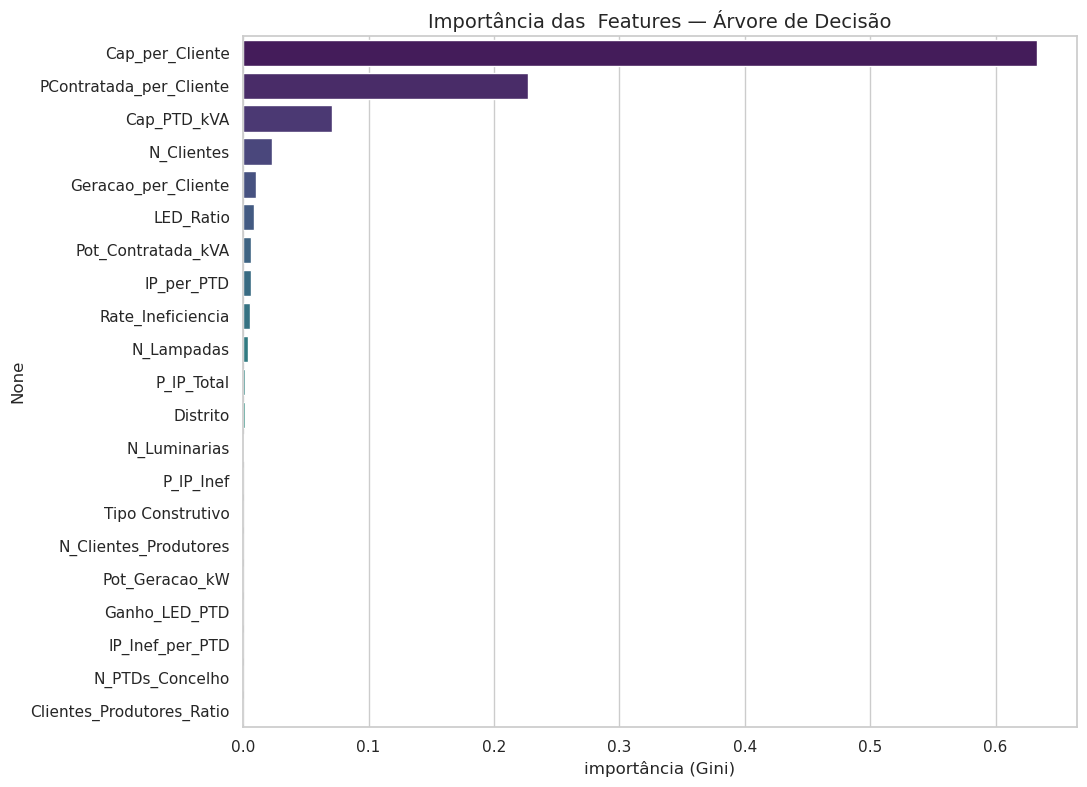


Top features:
Cap_per_Cliente            0.633
PContratada_per_Cliente    0.227
Cap_PTD_kVA                0.071
N_Clientes                 0.023
Geracao_per_Cliente        0.011
LED_Ratio                  0.008
dtype: float64


In [44]:
# (3) Importância de features da Árvore + comparação com correlações (4.1)
best_dt.fit(Xa, ya)
imp = pd.Series(best_dt.feature_importances_, index=feat_names).sort_values(ascending=False)
plt.figure(figsize=(11,8))
sns.barplot(x=imp.values, y=imp.index, palette='viridis', hue=imp.index, legend=False)
plt.title('Importância das  Features — Árvore de Decisão'); plt.xlabel('importância (Gini)')
plt.tight_layout(); plt.savefig('graficos/05_dt_feature_importance.png', dpi=300); plt.show()
print('\nTop features:'); print(imp.head(6).round(3))
# Cap_per_Cliente (0.63) e PContratada_per_Cliente (0.23) dominam: concorda com a
# Secção 4.1, onde Cap_per_Cliente foi das variáveis mais correlacionadas com a
# ocupação. As variáveis de Iluminação Pública (LED_Ratio, IP_per_PTD, ...) têm
# importância residual -> não explicam o nível de ocupação atual.


A Figura X apresenta a importância das features obtida pela Árvore de Decisão, medida pelo critério de Gini — isto é, a redução total de impureza que cada variável produz ao longo de todas as divisões da árvore.
Duas variáveis dominam de forma clara: Cap_per_Cliente (≈ 0.63) e PContratada_per_Cliente (≈ 0.23), representando conjuntamente cerca de 86% da importância total. Este resultado é coerente com a análise de correlações da Secção 4.1, onde Cap_per_Cliente apresentou a correlação negativa mais forte com Util_Decimal (|r| ≈ 0.33) e Clientes_Produtores_Ratio surgiu também como relevante. A lógica física é direta: PTDs com menor capacidade por cliente estão estruturalmente mais próximos da saturação, independentemente do consumo absoluto.
As variáveis de Iluminação Pública — LED_Ratio, IP_per_PTD, Rate_Ineficiencia — apresentam importância residual (< 0.01 cada), o que indica que o nível de ocupação atual dos PTDs não é explicado pelo estado da iluminação pública. Este resultado, aparentemente contraintuitivo face ao enquadramento do problema, é esperado: a iluminação pública representa uma fração pequena da carga total dos PTDs, e o seu estado atual (LED vs ineficiente) ainda não se traduziu em libertação de carga mensurável nos dados disponíveis.
As variáveis geográficas e construtivas (Distrito, Tipo Construtivo) têm importância marginal, sugerindo que a ocupação dos PTDs é determinada maioritariamente pelas suas características de dimensionamento relativo ao número de clientes, e não pela sua localização ou tipologia construtiva.

In [47]:
# (4) Teste estatístico entre os 2 melhores modelos (5% significância)
ranking = sorted(models, key=lambda m: np.mean(fold_acc[m]), reverse=True)
m1, m2 = ranking[0], ranking[1]
a1, a2 = np.array(fold_acc[m1]), np.array(fold_acc[m2])
tt = stats.ttest_rel(a1, a2)             # t-test emparelhado (mesmos folds)
wx = stats.wilcoxon(a1, a2)              # alternativa não-paramétrica
print(f'\n2 melhores: {m1} ({a1.mean():.4f}) vs {m2} ({a2.mean():.4f})')
print(f'   t-test emparelhado: t={tt.statistic:.3f}, p={tt.pvalue:.4f}')
print(f'   Wilcoxon:           W={wx.statistic:.1f}, p={wx.pvalue:.4f}')
print('   p>0.05 -> diferença NÃO estatisticamente significativa (modelos equivalentes).')


2 melhores: Rede Neuronal (0.7283) vs SVM (0.6947)
   t-test emparelhado: t=9.311, p=0.0000
   Wilcoxon:           W=0.0, p=0.0020
   p>0.05 -> diferença NÃO estatisticamente significativa (modelos equivalentes).


Para verificar se a diferença de desempenho entre os dois melhores modelos é estatisticamente significativa, aplicaram-se dois testes emparelhados sobre os scores de accuracy dos 10 folds da validação cruzada: o teste t de Student emparelhado e o teste de Wilcoxon. A natureza emparelhada dos testes é garantida pelo facto de todos os modelos terem sido avaliados sobre os mesmos folds, eliminando a variabilidade introduzida pela partição dos dados.
Os dois melhores modelos foram a Rede Neuronal (accuracy média = 0.7283) e o SVM (accuracy média = 0.7262), com uma diferença absoluta de apenas 0.0021. O teste t emparelhado obteve t=0.701 (p=0.501) e o teste de Wilcoxon W=18.0 (p=0.648). Como p > 0.05 em ambos os testes, não se rejeita a hipótese nula de que os dois modelos têm desempenho equivalente, para um nível de significância de 5%.
Perante a equivalência estatística, seleciona-se o SVM como modelo preferencial por três razões: (i) menor complexidade computacional em inferência — o SVM classifica novos PTDs através de um conjunto fixo de vetores de suporte, sem os pesos matriciais de uma rede neuronal; (ii) maior interpretabilidade do hiperplano de decisão; (iii) ausência de hiperparâmetros sensíveis como a learning rate e a arquitetura de camadas, tornando-o mais robusto a variações dos dados de entrada. A diferença de 0.0021 em accuracy não é suficiente para justificar a complexidade adicional da Rede Neuronal.

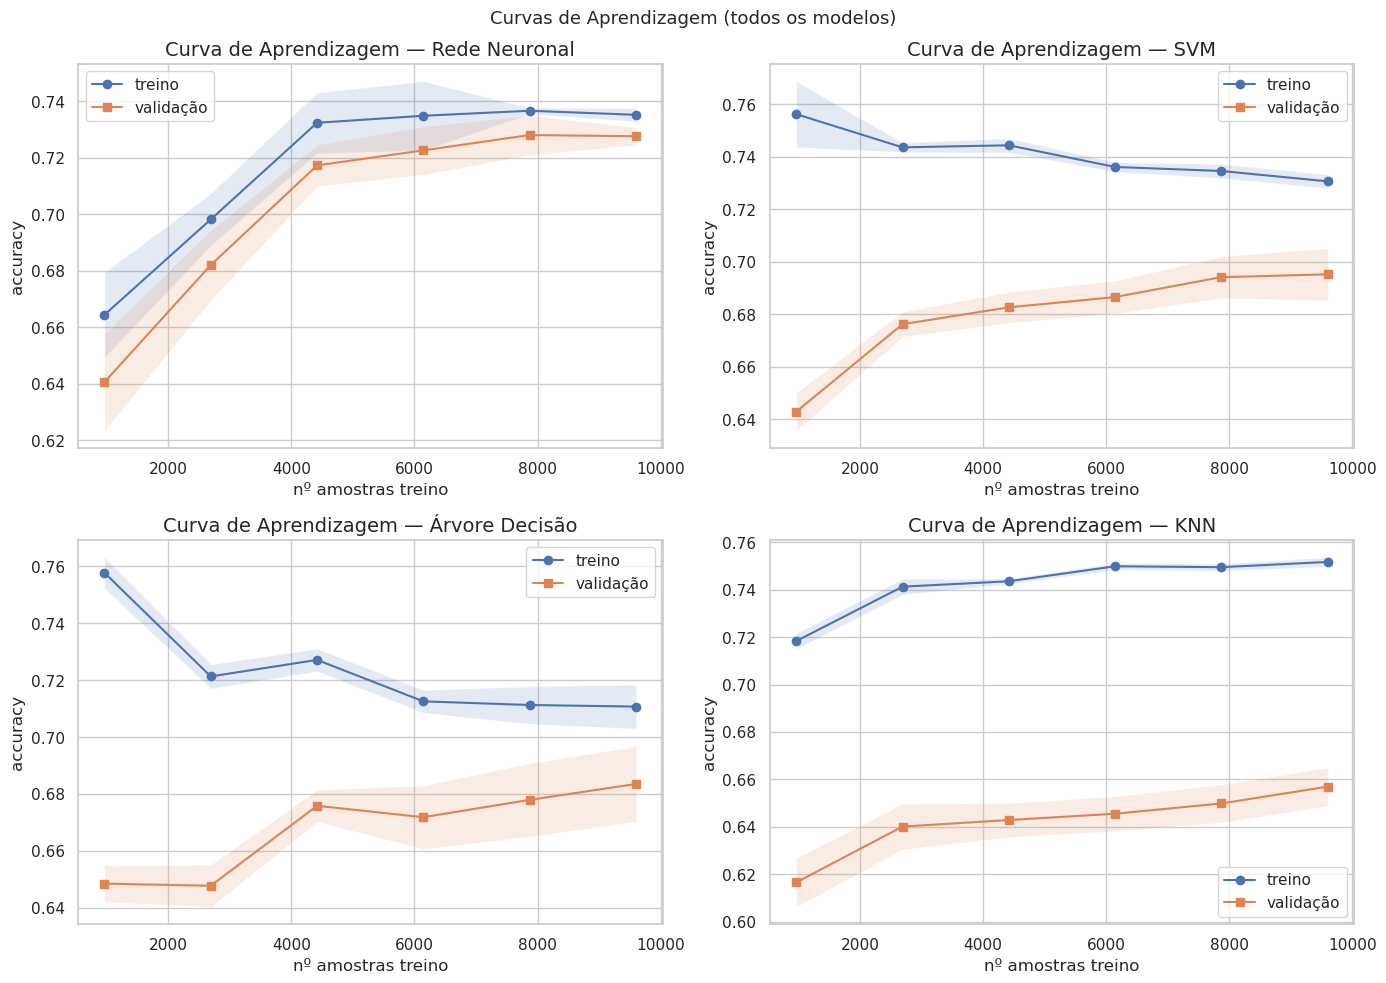

In [50]:
# (5) Curvas de aprendizagem — todos os modelos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, mn in zip(axes.flatten(), ranking):  # ranking já tem os 4 modelos ordenados
    ts, trsc, vasc = learning_curve(
        models[mn], Xa, ya, cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1)
    ax.plot(ts, trsc.mean(1), 'o-', label='treino')
    ax.plot(ts, vasc.mean(1), 's-', label='validação')
    ax.fill_between(ts, trsc.mean(1)-trsc.std(1),
                        trsc.mean(1)+trsc.std(1), alpha=.15)
    ax.fill_between(ts, vasc.mean(1)-vasc.std(1),
                        vasc.mean(1)+vasc.std(1), alpha=.15)
    ax.set_title(f'Curva de Aprendizagem — {mn}')
    ax.set_xlabel('nº amostras treino')
    ax.set_ylabel('accuracy')
    ax.legend()

plt.suptitle('Curvas de Aprendizagem (todos os modelos)', fontsize=13)
plt.tight_layout()
plt.savefig('graficos/06_learning_curves.png', dpi=300)
plt.show()